# 01 — Data Loading & Cleaning

Load the Jurisoo results dataset, filter to 1998+, and prep for modeling.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')
from src.data import load_results, filter_competitive
from src.rankings import load_rankings, RankingLookup

%matplotlib inline

## Load & Filter

In [2]:
df = load_results('../data/raw/results.csv', since_year=1980, former_names_path='../data/raw/former_names.csv')
print(df.shape)
df.head()

(37126, 9)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1980-01-06,Sierra Leone,Ghana,2.0,4.0,Friendly,Freetown,Sierra Leone,False
1,1980-01-16,Cyprus,Greece,1.0,1.0,Friendly,Nicosia,Cyprus,False
2,1980-01-19,Congo,Ivory Coast,2.0,0.0,Friendly,Brazzaville,Congo,False
3,1980-01-20,Congo,Ivory Coast,0.0,2.0,Friendly,Brazzaville,Congo,False
4,1980-01-23,Spain,Netherlands,1.0,0.0,Friendly,Vigo,Spain,False


In [3]:
# Tournament breakdown
df['tournament'].value_counts().head(20)

tournament
Friendly                                12630
FIFA World Cup qualification             7778
UEFA Euro qualification                  2350
African Cup of Nations qualification     2079
African Cup of Nations                    722
AFC Asian Cup qualification               718
UEFA Nations League                       658
FIFA World Cup                            656
CFU Caribbean Cup qualification           580
CECAFA Cup                                547
Copa América                              441
CONCACAF Nations League                   422
Gold Cup                                  420
Island Games                              394
AFC Asian Cup                             370
UEFA Euro                                 367
COSAFA Cup                                354
Gulf Cup                                  338
AFF Championship                          291
CFU Caribbean Cup                         240
Name: count, dtype: int64

In [4]:
# Filter to competitive matches only (drop friendlies)
df_comp = filter_competitive(df)
print(f'All: {len(df):,}  |  Competitive: {len(df_comp):,}')

All: 37,126  |  Competitive: 21,220


In [5]:
# Tournament audit — all unique names passing the competitive filter
pd.Series(df_comp['tournament'].unique()).sort_values().reset_index(drop=True)

0                             AFC Asian Cup
1               AFC Asian Cup qualification
2                         AFC Challenge Cup
3           AFC Challenge Cup qualification
4                          AFF Championship
5            AFF Championship qualification
6                        ASEAN Championship
7          ASEAN Championship qualification
8                    African Cup of Nations
9      African Cup of Nations qualification
10                                 Arab Cup
11                   Arab Cup qualification
12                British Home Championship
13                         CAFA Nations Cup
14                               CECAFA Cup
15                        CFU Caribbean Cup
16          CFU Caribbean Cup qualification
17                    CONCACAF Championship
18      CONCACAF Championship qualification
19                  CONCACAF Nations League
20    CONCACAF Nations League qualification
21           CONMEBOL–UEFA Cup of Champions
22                              

## Basic EDA

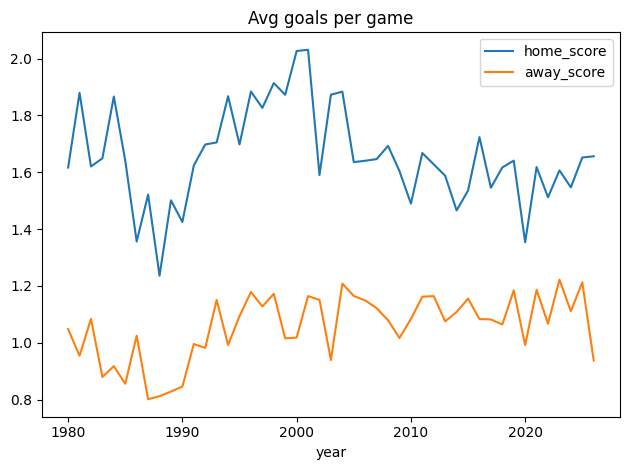

In [6]:
# Goals per game over time
df_comp['year'] = df_comp['date'].dt.year
df_comp.groupby('year')[['home_score','away_score']].mean().plot(title='Avg goals per game')
plt.tight_layout()

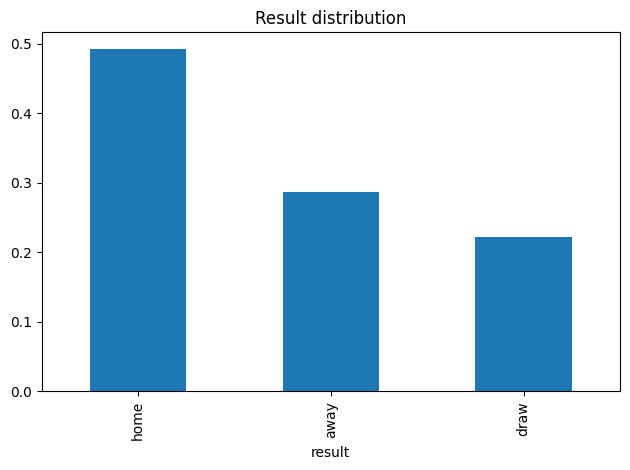

In [7]:
# Home win / draw / away win rates
df_comp['result'] = df_comp.apply(
    lambda r: 'home' if r.home_score > r.away_score else ('draw' if r.home_score == r.away_score else 'away'), axis=1
)
df_comp['result'].value_counts(normalize=True).plot(kind='bar', title='Result distribution')
plt.tight_layout()

In [8]:
# Add pre-match FIFA rankings for both teams
rankings_df = load_rankings(
    '../data/raw/fifa_ranking-2024-06-20.csv',
    scraped_path='../data/raw/fifa_ranking_scraped.csv',
)
lookup = RankingLookup(rankings_df)

home_ranks, away_ranks = [], []
for _, row in df_comp.iterrows():
    home_ranks.append(lookup.get(row['home_team'], row['date']))
    away_ranks.append(lookup.get(row['away_team'], row['date']))

df_comp['home_fifa_rank']   = [r['rank'] for r in home_ranks]
df_comp['away_fifa_rank']   = [r['rank'] for r in away_ranks]
df_comp['home_fifa_points'] = [r['total_points'] for r in home_ranks]
df_comp['away_fifa_points'] = [r['total_points'] for r in away_ranks]

# How many matches have rankings for both teams?
both = df_comp['home_fifa_rank'].notna() & df_comp['away_fifa_rank'].notna()
print(f'Matches with rankings for both teams: {both.sum():,} / {len(df_comp):,}')
df_comp[both].head()

Matches with rankings for both teams: 19,636 / 21,220


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,result,home_fifa_rank,away_fifa_rank,home_fifa_points,away_fifa_points
0,1980-02-06,England,Republic of Ireland,2.0,0.0,UEFA Euro qualification,London,England,False,1980,home,5.0,6.0,55.0,54.0
1,1980-02-24,Vanuatu,Papua New Guinea,3.0,4.0,Oceania Nations Cup,Nouméa,New Caledonia,True,1980,away,159.0,179.0,0.0,1.0
2,1980-02-24,New Caledonia,Australia,0.0,8.0,Oceania Nations Cup,Nouméa,New Caledonia,False,1980,away,186.0,45.0,119.0,29.0
3,1980-02-25,New Zealand,Tahiti,1.0,3.0,Oceania Nations Cup,Nouméa,New Caledonia,True,1980,away,70.0,123.0,22.0,5.0
4,1980-02-25,Fiji,Solomon Islands,3.0,1.0,Oceania Nations Cup,Nouméa,New Caledonia,True,1980,home,106.0,136.0,9.0,2.0


In [9]:
# Save cleaned data
df_comp.to_csv('../data/processed/matches_competitive.csv', index=False)
print('Saved.')

Saved.
